### Imports

In [232]:
import numpy as np
import scipy  
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

Like before, let's generate some fake data.

In [233]:
import importlib
import simulate_ccd_data as ccd
importlib.reload(ccd)

truth = ccd.generate_all("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data")

Wrote 9 bias, 5 dark, 10 flat, 10 light frames to /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/
Cluster: 300 stars at 1200.0 pc (distance modulus 10.40), field center RA=132.8490 Dec=11.8000
47 star(s) saturate in a 60s light frame -- expected for the brightest cluster members, exclude them from photometry.
Ground-truth catalog (for checking your results, not something you'd have for real data): /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/truth_catalog_ANSWER_KEY.csv


In the process of astronomical image analysis, the first few steps are stacking and creating master frames, such that we can subtract them from our light frames, removing read noise and dark current.

Starting with the master bias, which we compute by simply stacking the bias frames and adding them in a linear fashion.

In [234]:
import ccdproc
from pathlib import Path
import astropy.units as u

bias_dir = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/bias/")

bias_files = list(bias_dir.glob("*.fits"))
master_bias = ccdproc.combine(bias_files, method="median", unit=u.adu)
master_bias.write(bias_dir / "master_bias.fits", overwrite=True)

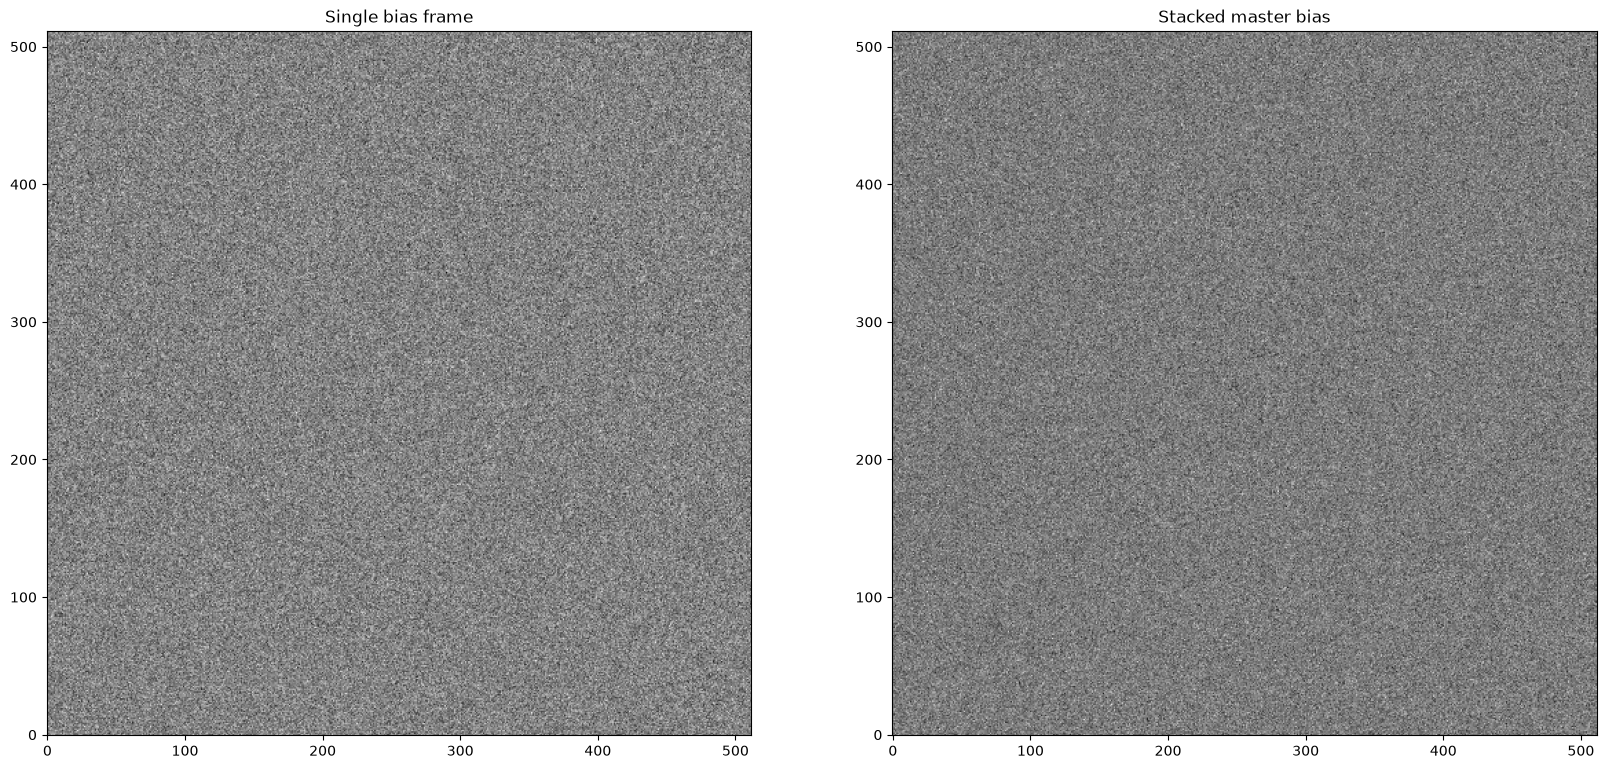

In [235]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

single_bias_path = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/bias/bias_004.fits"
master_bias_path = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/bias/master_bias.fits"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.imshow(fits.getdata(single_bias_path), cmap="gray", origin="lower")
ax1.set_title("Single bias frame")

ax2.imshow(fits.getdata(master_bias_path), cmap="gray", origin="lower")
ax2.set_title("Stacked master bias")

plt.show()

Now, moving on to the master dark, we can form this by subtracting from each dark frame the master bias, and then median-combining the resulting master-bias-subtracted darks.

In [236]:
import ccdproc
from pathlib import Path
import astropy.units as u

dark_dir = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/dark/")
bias_dir = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/bias/")
dark_files = list(dark_dir.glob("*.fits"))

mb_subtracted_darks = []
for dark_file in dark_files:
    dark = ccdproc.CCDData.read(dark_file, unit=u.adu)
    corrected_dark = ccdproc.subtract_bias(dark, master_bias)
    mb_subtracted_darks.append(corrected_dark)

master_dark = ccdproc.combine(mb_subtracted_darks, method="median")
master_dark.write(dark_dir / "master_dark.fits", overwrite=True)

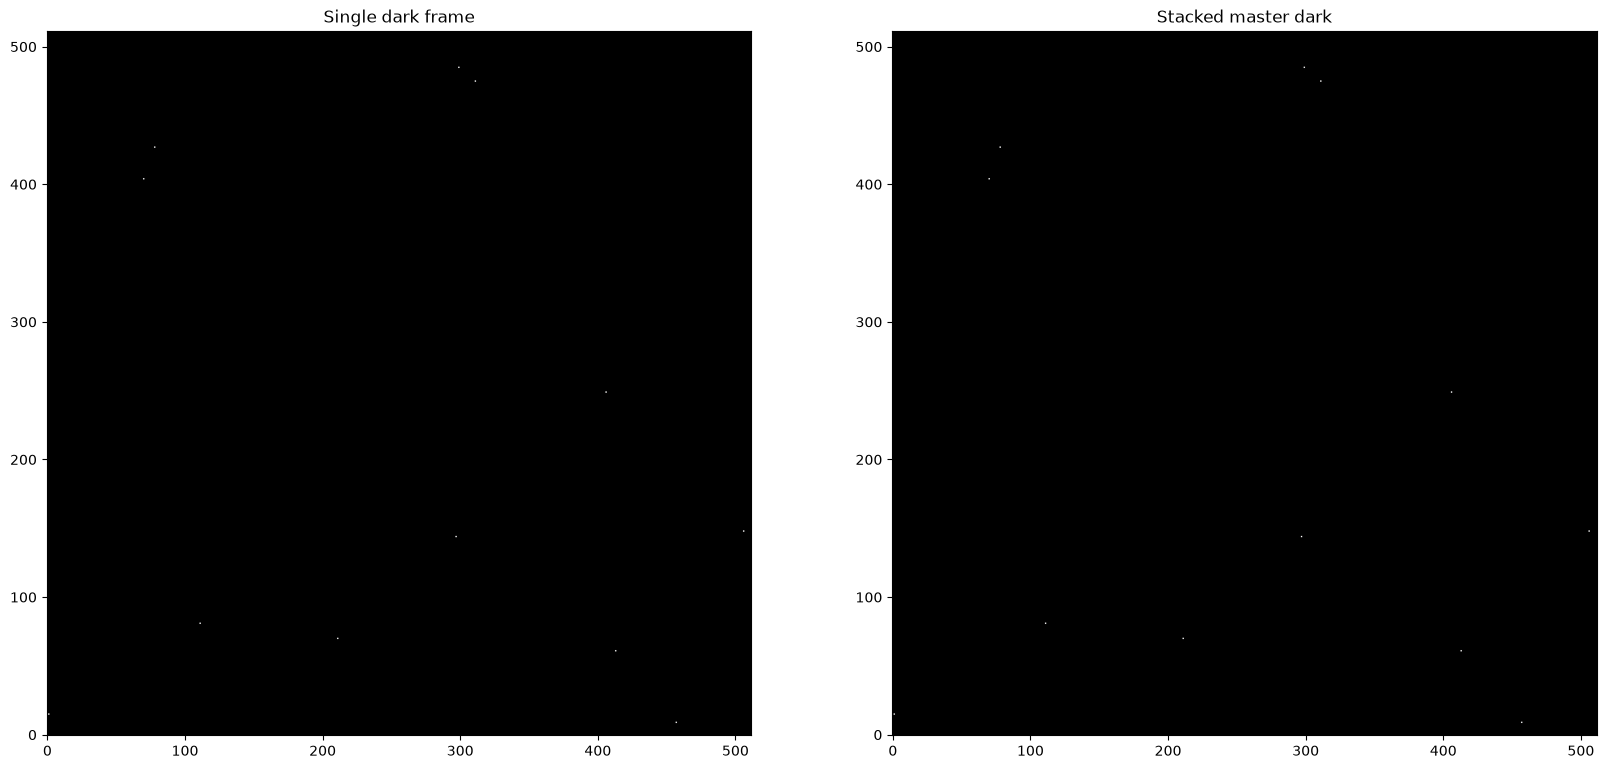

In [237]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

single_dark_path = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/dark/dark_60s_000.fits"
master_dark_path = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/dark/master_dark.fits"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.imshow(fits.getdata(single_dark_path), cmap="gray", origin="lower")
ax1.set_title("Single dark frame")

ax2.imshow(fits.getdata(master_dark_path), cmap="gray", origin="lower")
ax2.set_title("Stacked master dark")

plt.show()

For the master flat, which we must do by filter, we take the individual flats, subtract the master bias, and we subtract the master dark, scaled to match the exposure time of the flat frames, which in this case, is 3 seconds. That is,
\begin{equation}
    F_\text{corr} = F_\text{raw} - B - \frac{t_F}{t_D}D, 
\end{equation}
where $B$ is the master bias, $D$ is the master dark, $t_F$ is the flat exposure time (3 seconds), and $t_D$ is the dark exposure time (60 seconds).

Afterwards, we take the median of the stack, that is, compute $F_X = \text{median}(F_\text{coor})$, and then normalize the master flat:
\begin{equation}
    \tilde{F}_X = \frac{F_X}{\text{median}(F_X)}
\end{equation}

In [238]:
import ccdproc
from pathlib import Path
import astropy.units as u
from astropy.nddata import CCDData


flat_dir = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/flat/")
bias_path = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/bias/master_bias.fits")
dark_path = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/dark/master_dark.fits")
flat_files = list(flat_dir.glob("*.fits"))

master_bias = ccdproc.CCDData.read(bias_path, unit=u.adu)
master_dark = ccdproc.CCDData.read(dark_path, unit=u.adu)

flats_by_filter = {}
for flat_file in flat_files:
    flat = ccdproc.CCDData.read(flat_file, unit=u.adu)
    filt = flat.meta["FILTER"]
    sub_bias = ccdproc.subtract_bias(flat, master_bias)
    sub_dark = ccdproc.subtract_dark(sub_bias, master_dark, dark_exposure=60 * u.s, data_exposure=3 * u.s, scale=True)
    if filt not in flats_by_filter:
        flats_by_filter[filt] = []
    flats_by_filter[filt].append(sub_dark)

master_flats = {}
for filt, flats in flats_by_filter.items():
    master_flat = ccdproc.combine(flats, method="median")
    normalized_data = master_flat.data / np.median(master_flat.data)
    normalized_flat = CCDData(normalized_data, unit=master_flat.unit, meta=master_flat.meta)
    master_flat_path = flat_dir / f"master_flat_{filt}.fits"
    normalized_flat.write(master_flat_path, overwrite=True)
    master_flats[filt] = normalized_flat

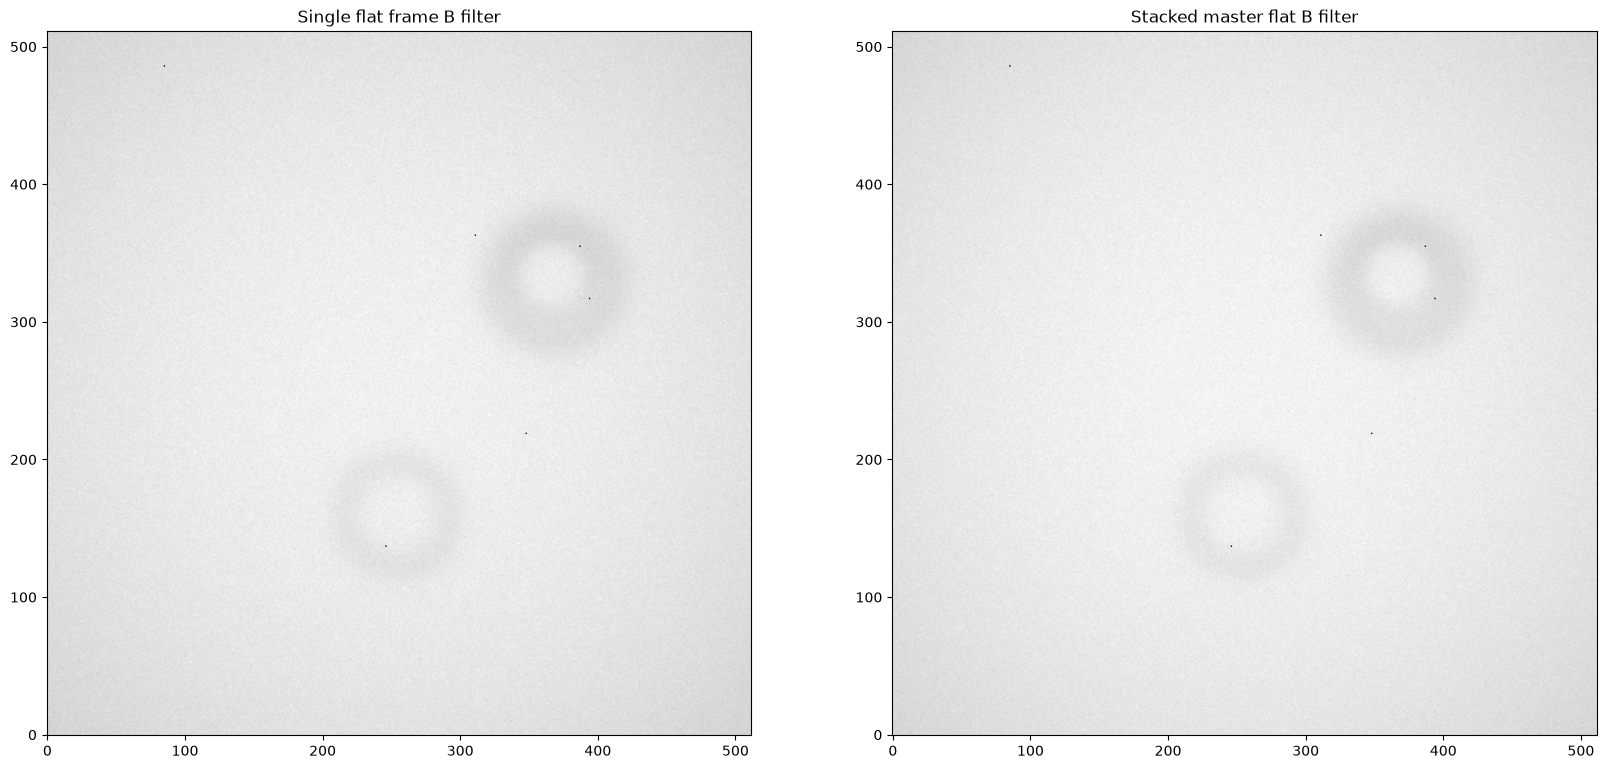

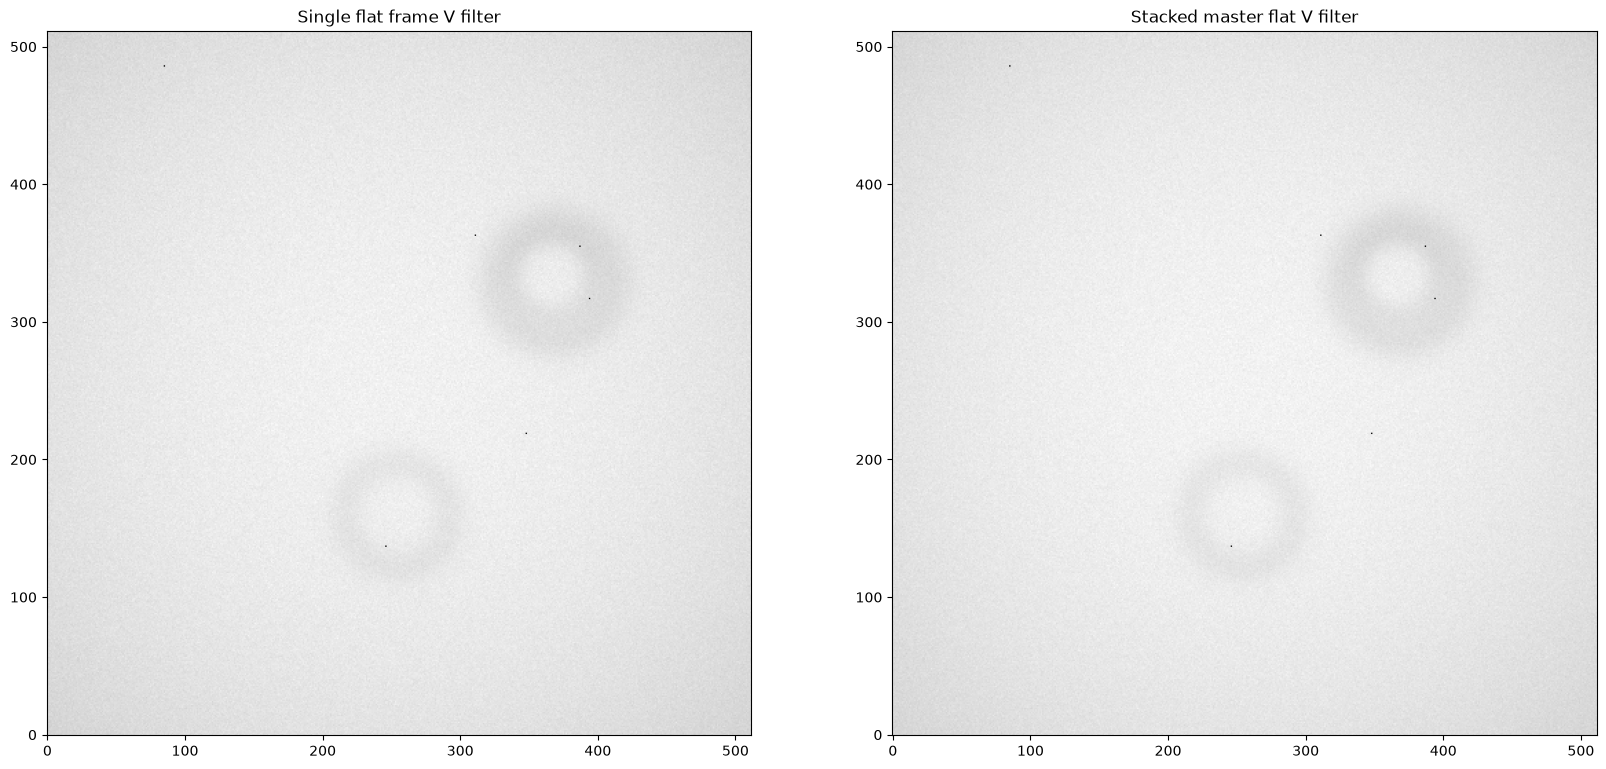

In [239]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

single_flat_B = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/flat/flat_B_000.fits"
master_flat_B = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/flat/master_flat_B.fits"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(fits.getdata(single_flat_B), cmap="gray", origin="lower")
ax1.set_title("Single flat frame B filter")
ax2.imshow(fits.getdata(master_flat_B), cmap="gray", origin="lower")
ax2.set_title("Stacked master flat B filter")
plt.show()

single_flat_V = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/flat/flat_V_000.fits"
master_flat_V = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/flat/master_flat_V.fits"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(fits.getdata(single_flat_V), cmap="gray", origin="lower")
ax1.set_title("Single flat frame V filter")
ax2.imshow(fits.getdata(master_flat_V), cmap="gray", origin="lower")
ax2.set_title("Stacked master flat V filter")
plt.show()

And finally, for the light frames themselves, we have to subtract the maser bias, subtract the master dark, and then flat correct the resulting images using our master flat frame, all done per filter. That is, 

\begin{equation}
    L_\text{corr} = \frac{L_\text{raw} - B - D}{F_X}
\end{equation}

In [240]:
import ccdproc
from pathlib import Path
import astropy.units as u
from astropy.nddata import CCDData

bias_path = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/bias/master_bias.fits")
dark_path = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/dark/master_dark.fits")
light_dir = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/light/")
light_files = list(light_dir.glob("*.fits"))

calibrated_dir = light_dir.parent / "calibrated_light"
calibrated_dir.mkdir(exist_ok=True)

master_bias = ccdproc.CCDData.read(bias_path, unit=u.adu)
master_dark = ccdproc.CCDData.read(dark_path, unit=u.adu)

calibrated_lights_by_filter = {}
for light_file in light_files:
    light = ccdproc.CCDData.read(light_file, unit=u.adu)
    filt = light.meta["FILTER"]
    light_exposure = light.meta["EXPTIME"] * u.s
    flat_path = light_dir.parent / "flat" / f"master_flat_{filt}.fits"
    master_flat = ccdproc.CCDData.read(flat_path, unit=u.adu)

    sub_bias = ccdproc.subtract_bias(light, master_bias)
    sub_dark = ccdproc.subtract_dark(sub_bias, master_dark, dark_exposure=60 * u.s, data_exposure=light_exposure, scale=True)
    calibrated = ccdproc.flat_correct(sub_dark, master_flat)

    if filt not in calibrated_lights_by_filter:
        calibrated_lights_by_filter[filt] = []

    calibrated_lights_by_filter[filt].append(calibrated)
    output_path = calibrated_dir / f"{light_file.stem}_calibrated.fits"
    calibrated.write(output_path, overwrite=True)

Or, as this is more common, let us view the image using an applied Asinh stretch, which basically just shows the image in log space.

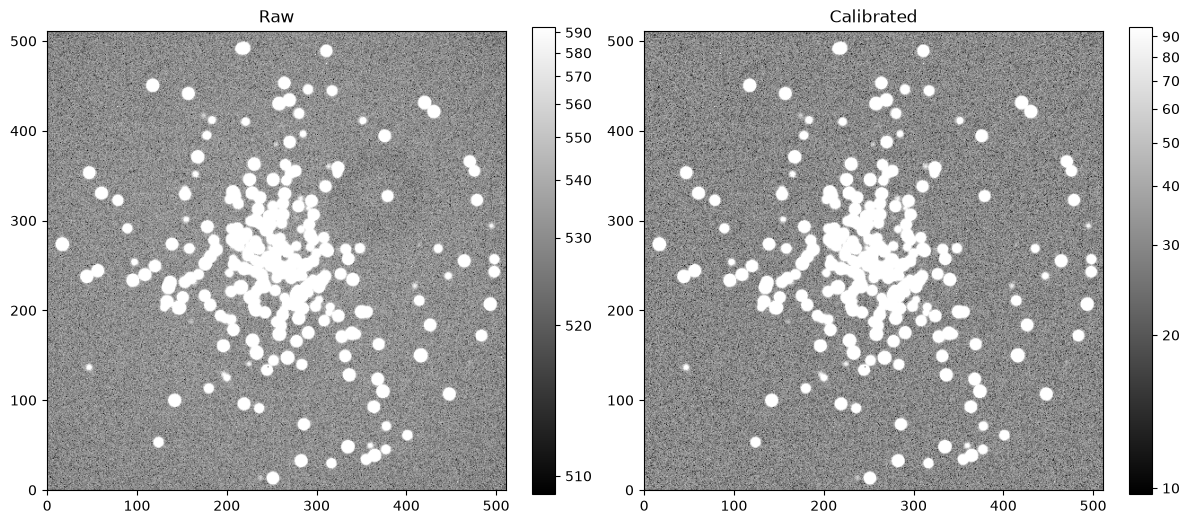

In [241]:
import matplotlib.pyplot as plt
from astropy.nddata import CCDData
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch

raw = CCDData.read("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/light/light_B_000.fits", unit="adu")
cal = CCDData.read("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/calibrated_light/light_B_000_calibrated.fits", unit="adu")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, img, title in zip(axes, [raw, cal], ["Raw", "Calibrated"]):
    data = img.data.astype(float)
    norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
    im = ax.imshow(data, origin="lower", cmap="grey", norm=norm)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Now, having calibrated all of our light frames, we can continue onwards with a sky subtraction. For each calibrated image, we can estimate the background by taking the median of the light frame, and making a sky-subtracted copy, that is,

\begin{equation}
    I_\text{sky} = L_\text{calibrated} - S, \ \ \ S = \text{median(sigma-clipped pixels)}. 
\end{equation}

We also choose a reference image that we can compare to, such that we don't need to detect stars independently in all 10 images.

In [242]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.nddata import CCDData

sky_subtracted_frames = {}
sky = {}

for filt, frames in calibrated_lights_by_filter.items():
    sky_subtracted_frames[filt] = []
    for i, ccd in enumerate(frames):
        mean, median, std = sigma_clipped_stats(ccd.data, sigma=3, maxiters=5)
        sky[filt, i] = {"mean": mean, "median": median, "std": std}
        sky_subtracted = ccd.copy()
        sky_subtracted.data = ccd.data - median
        sky_subtracted_frames[filt].append(sky_subtracted)
        print(
            f"{filt} frame {i+1}: "
            f"sky = {median:.2f}, "
            f"sigma = {std:.2f}"
        )    

B_reference = sky_subtracted_frames["B"][0]
V_reference = sky_subtracted_frames["V"][0]

V frame 1: sky = 41.81, sigma = 8.85
V frame 2: sky = 41.76, sigma = 8.82
V frame 3: sky = 41.77, sigma = 8.84
V frame 4: sky = 41.77, sigma = 8.85
V frame 5: sky = 41.77, sigma = 8.88
B frame 1: sky = 31.05, sigma = 8.77
B frame 2: sky = 31.08, sigma = 8.83
B frame 3: sky = 31.05, sigma = 8.81
B frame 4: sky = 31.06, sigma = 8.81
B frame 5: sky = 31.04, sigma = 8.69


Now, to actually detect the stars on the reference image, we can use ``DAOStarFinder`` which, conceptually, takes in a reference image and returns coordinate positions ${(x_i, y_i)}^N_{i=1}$ for $N$ stars. Loading our reference frames:

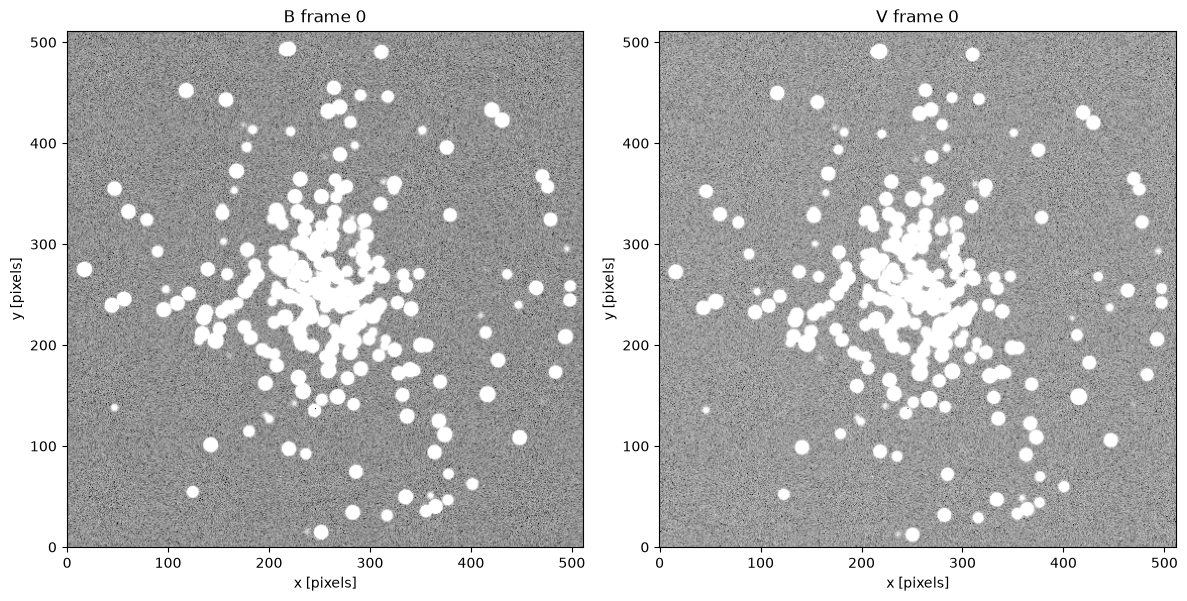

In [243]:
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, ccd, title in zip(axes, [B_reference, V_reference], ["B frame 0", "V frame 0"]):
    data = ccd.data.astype(float)
    norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
    ax.imshow(data, origin="lower", cmap="gray", norm=norm)
    ax.set_title(title)
    ax.set_xlabel("x [pixels]")
    ax.set_ylabel("y [pixels]")

plt.tight_layout()
plt.show()

Let us now run ``DAOStarFinder``, where can start with the expected FWHM of 4.4 pixels and the measured sky noise from each frame.

In [244]:
from photutils.detection import DAOStarFinder

B_std = sky["B", 0]["std"]
V_std = sky["V", 0]["std"]

fwhm = 4.4

B_threshold = 5 * B_std
V_threshold = 5 * V_std

B_finder = DAOStarFinder(fwhm=fwhm, threshold=B_threshold)
V_finder = DAOStarFinder(fwhm=fwhm, threshold=V_threshold)

B_sources = B_finder(B_reference.data)
V_sources = V_finder(V_reference.data)

print(f"B detections: {len(B_sources)}")
print(f"V detections: {len(V_sources)}")

B detections: 141
V detections: 132


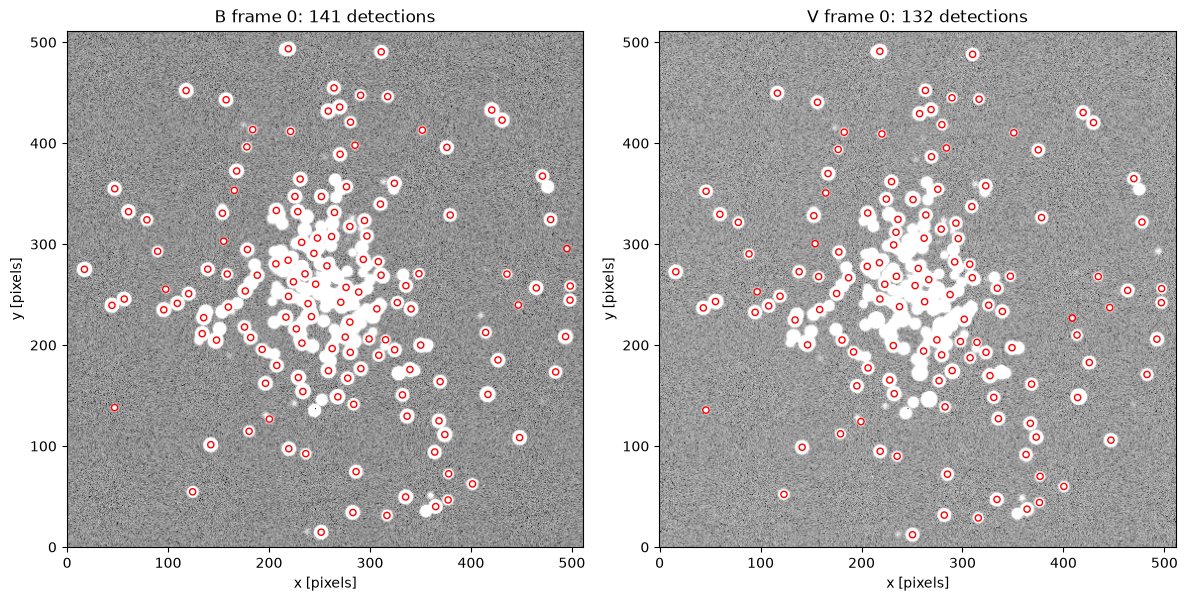

 id     x_centroid     ...         mag             daofind_mag    
--- ------------------ ... ------------------- -------------------
  1 251.65014254610665 ... -14.412167341001128  -7.025402989453311
  2 316.79257545989424 ... -11.529196398073928  -4.177129603916391
  3  283.0986177124799 ... -14.535155558673637  -7.174912582878694
  4  365.1136590757526 ... -14.587204886894225  -7.232237478351767
  5 377.42009578523596 ...  -11.06564161970762  -3.647196618664323
  6 335.30558105037017 ...  -14.94731693255832  -7.552721763984193
  7 124.31493498454415 ...  -11.85465579629183  -4.471187875975095
  8 401.57402220288105 ... -11.723595725851224  -4.284422161369123
  9 377.93201006599276 ... -10.785618127985304 -3.3868112435583764
 10  286.2455283070854 ...  -13.68795689805534  -6.298698568810368
...                ... ...                 ...                 ...
132 258.73832760727794 ... -15.157308106619961  -7.279194918589438
133 420.66357025009387 ...  -15.08582670742367  -7.57527634621

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, ccd, sources, title in zip(axes, [B_reference, V_reference], [B_sources, V_sources], ["B frame 0", "V frame 0"]):
    data = ccd.data.astype(float)
    norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
    ax.imshow(data, origin="lower", cmap="gray", norm=norm)
    ax.scatter(sources["x_centroid"], sources["y_centroid"], s=20, facecolors="none", edgecolors="red")
    ax.set_title(f"{title}: {len(sources)} detections")
    ax.set_xlabel("x [pixels]")
    ax.set_ylabel("y [pixels]")

plt.tight_layout()
plt.show()

print(B_sources)
print(V_sources)

print(B_reference.wcs)
print(V_reference.wcs)

With ``DAOStarFinder`` having succeeded, let us now establish the coordinates of the stars using WCS, which converts them to sky coordinates $(\alpha_i, \delta_i)$.

In [246]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

B_x = np.array(B_sources["x_centroid"])
B_y = np.array(B_sources["y_centroid"])

V_x = np.array(V_sources["x_centroid"])
V_y = np.array(V_sources["y_centroid"])

B_coords = B_reference.wcs.pixel_to_world(B_x, B_y)
V_coords = V_reference.wcs.pixel_to_world(V_x, V_y)

B_sources["ra"] = B_coords.ra.deg
B_sources["dec"] = B_coords.dec.deg
V_sources["ra"] = V_coords.ra.deg
V_sources["dec"] = V_coords.dec.deg

idx, sep2d, _ = B_coords.match_to_catalog_sky(V_coords)

print("Median separation:", np.median(sep2d).to(u.arcsec))
print("Maximum separation:", np.max(sep2d).to(u.arcsec))

match_radius = 1.0 * u.arcsec
good_matches = sep2d < match_radius

print("B detections:", len(B_sources))
print("V detections:", len(V_sources))
print("Matched stars:", np.sum(good_matches))

B_match = B_sources[good_matches]
V_match = V_sources[idx[good_matches]]

matched_sep = sep2d[good_matches]

print("Matched:", np.sum(good_matches))
print("Rejected:", np.sum(~good_matches))

print("Largest accepted separation:", np.max(sep2d[good_matches]).to(u.arcsec))
print("Smallest rejected separation:", np.min(sep2d[~good_matches]).to(u.arcsec))

Median separation: 0.0158759 arcsec
Maximum separation: 16.5275 arcsec
B detections: 141
V detections: 132
Matched stars: 123
Matched: 123
Rejected: 18
Largest accepted separation: 0.883721 arcsec
Smallest rejected separation: 1.12537 arcsec


Now, taking what we have done here for the reference frame and extending the analysis to all the frames:

In [248]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
from astropy.table import Table

B_match = B_sources[good_matches]
V_match = V_sources[idx[good_matches]]

star_catalog = Table()

star_catalog["star_id"] = np.arange(len(B_match))

star_catalog["ra"] = B_match["ra"]
star_catalog["dec"] = B_match["dec"]

star_catalog["B_x_ref"] = B_match["x_centroid"]
star_catalog["B_y_ref"] = B_match["y_centroid"]

star_catalog["V_x_ref"] = V_match["x_centroid"]
star_catalog["V_y_ref"] = V_match["y_centroid"]

star_catalog["BV_sep_arcsec"] = (
    sep2d[good_matches].to(u.arcsec).value
)

print(f"Master catalog contains {len(star_catalog)} stars")

master_coords = SkyCoord(ra=star_catalog["ra"] * u.deg, dec=star_catalog["dec"] * u.deg)
positions_by_filter = {}
for filt, frames in sky_subtracted_frames.items():
    positions_by_filter[filt] = []
    for i, ccd in enumerate(frames):
        x, y = ccd.wcs.world_to_pixel(master_coords)
        positions_by_filter[filt].append({"frame": i, "x": x, "y": y})
        print(
            f"{filt} frame {i+1}: "
            f"x range = ({x.min():.2f}, {x.max():.2f}), "
            f"y range = ({y.min():.2f}, {y.max():.2f})"
        )

Master catalog contains 123 stars
V frame 1: x range = (16.02, 497.27), y range = (12.14, 491.00)
V frame 2: x range = (14.87, 496.12), y range = (17.98, 496.83)
V frame 3: x range = (14.71, 495.97), y range = (15.50, 494.35)
V frame 4: x range = (13.67, 494.92), y range = (14.41, 493.27)
V frame 5: x range = (15.39, 496.64), y range = (16.16, 495.02)
B frame 1: x range = (17.14, 498.39), y range = (14.65, 493.51)
B frame 2: x range = (17.87, 499.12), y range = (15.05, 493.91)
B frame 3: x range = (13.02, 494.27), y range = (15.12, 493.98)
B frame 4: x range = (16.87, 498.13), y range = (13.17, 492.03)
B frame 5: x range = (13.59, 494.84), y range = (16.34, 495.20)


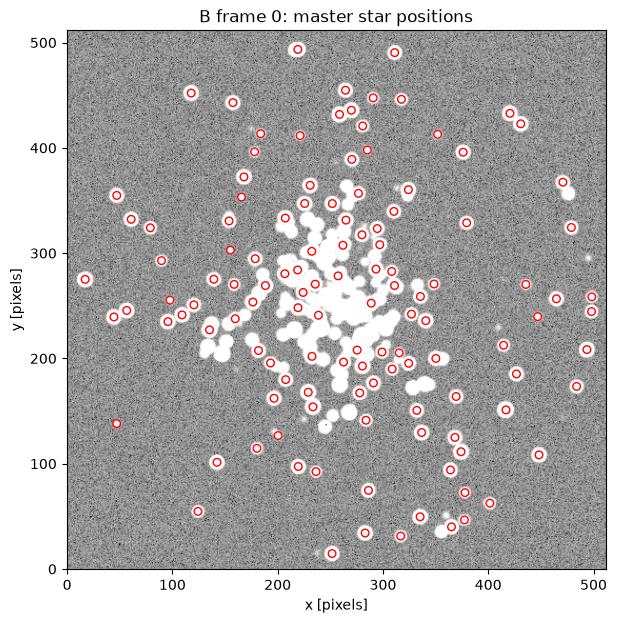

In [249]:
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch

fig, ax = plt.subplots(figsize=(7, 7))
data = B_reference.data.astype(float)

norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
ax.imshow(data, origin="lower", cmap="gray", norm=norm)
ax.scatter(positions_by_filter["B"][0]["x"], positions_by_filter["B"][0]["y"], s=30, facecolors="none", edgecolors="red")
ax.set_title("B frame 0: master star positions")
ax.set_xlabel("x [pixels]")
ax.set_ylabel("y [pixels]")
plt.show()

Having now found WCS coordinates for every frame in our sample, we can finally move on to aperture photometry.

In [250]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry

def do_aperture_photometry(ccd, x, y, r_ap=6.5, r_in=15, r_out=22):
    positions = np.column_stack([x, y])
    apertures = CircularAperture(positions, r=r_ap)
    annuli = CircularAnnulus(positions, r_in=r_in, r_out=r_out)
    phot = aperture_photometry(ccd.data, apertures)
    annulus_masks = annuli.to_mask(method="center")

    sky_medians = []
    sky_stds = []
    for mask in annulus_masks:
        annulus_data = mask.multiply(ccd.data)
        annulus_data_1d = annulus_data[mask.data > 0]
        _, sky_median, sky_std = sigma_clipped_stats(annulus_data_1d, sigma=3, maxiters=5)
        sky_medians.append(sky_median)
        sky_stds.append(sky_std)

    sky_medians = np.asarray(sky_medians)
    sky_stds = np.asarray(sky_stds)

    aperture_area = apertures.area
    flux = (np.asarray(phot["aperture_sum"]) - sky_medians * aperture_area)
    return {
        "aperture_sum": np.asarray(phot["aperture_sum"]),
        "sky": sky_medians,
        "sky_std": sky_stds,
        "flux": flux
    }

photometry = {}
for filt in ["B", "V"]:
    photometry[filt] = []
    for i, ccd in enumerate(sky_subtracted_frames[filt]):
        x = positions_by_filter[filt][i]["x"]
        y = positions_by_filter[filt][i]["y"]
        result = do_aperture_photometry(ccd, x, y)
        photometry[filt].append(result)
        print(
            f"{filt} frame {i}: "
            f"{len(result['flux'])} stars measured"
        )

B frame 0: 123 stars measured
B frame 1: 123 stars measured
B frame 2: 123 stars measured
B frame 3: 123 stars measured
B frame 4: 123 stars measured
V frame 0: 123 stars measured
V frame 1: 123 stars measured
V frame 2: 123 stars measured
V frame 3: 123 stars measured
V frame 4: 123 stars measured


Now that we have the fluxes of each star, we convert each measurement to an instrumental magnitude. For a 60 second exposure,
\begin{equation}
    m_\text{inst} = -2.5 \log_{10} \left(\frac{F}{t_\text{exp}}\right), 
\end{equation}
where $F$ is the sky-subtracted aperture flux in ADU.

We also want to take mean averages of each observation in the two filters to compute the mean instrumental magnitude, since each frame has five measurements of the same star:

In [251]:
import numpy as np

instrumental_mags = {}
for filt in ["B", "V"]:
    instrumental_mags[filt] = []
    for i, result in enumerate(photometry[filt]):
        exptime = sky_subtracted_frames[filt][i].meta["EXPTIME"]
        flux = result["flux"]
        mag = np.full(len(flux), np.nan)
        good = flux > 0
        mag[good] = -2.5 * np.log10(flux[good] / exptime)
        instrumental_mags[filt].append(mag)
        print(
            f"{filt} frame {i}: "
            f"{np.sum(good)}/{len(flux)} positive-flux measurements"
        )

print("B1 instrumental magnitudes:")
print(instrumental_mags["B"][0][:20])

print()

print("V1 instrumental magnitudes:")
print(instrumental_mags["V"][0][:20])

mean_inst_mag = {}
std_inst_mag = {}

for filt in ["B", "V"]:
    mags = np.array(instrumental_mags[filt])
    mean_inst_mag[filt] = np.nanmean(mags, axis=0)
    std_inst_mag[filt] = np.nanstd(mags, axis=0)
    print(
        f"{filt}: "
        f"median scatter = "
        f"{np.nanmedian(std_inst_mag[filt]):.4f} mag"
    )

B frame 0: 123/123 positive-flux measurements
B frame 1: 123/123 positive-flux measurements
B frame 2: 123/123 positive-flux measurements
B frame 3: 123/123 positive-flux measurements
B frame 4: 123/123 positive-flux measurements
V frame 0: 123/123 positive-flux measurements
V frame 1: 123/123 positive-flux measurements
V frame 2: 123/123 positive-flux measurements
V frame 3: 123/123 positive-flux measurements
V frame 4: 123/123 positive-flux measurements
B1 instrumental magnitudes:
[-10.41576581  -7.52320567 -10.52121629 -10.57370268  -7.07510902
 -10.95381015  -7.85315296  -7.74618205  -6.7855718   -9.68762636
  -7.32522295 -10.0901086  -10.31312463 -10.76027467 -10.66639049
 -11.1010877   -7.45123134 -10.46783857  -5.08864299 -10.60141366]

V1 instrumental magnitudes:
[ -9.68909078  -7.06895453  -9.78005261  -9.84431756  -6.61324913
 -10.17691777  -7.3026061   -7.19222305  -6.40998986  -8.96377639
  -6.91759904  -9.42853168  -9.58410623 -10.09096601  -9.9318986
 -10.35758711  -6.955

Constructing our first few diagnostic plots, showcasing the magnitudes of the two filters, which we expect to roughly comparable for most of the main sequence stars. We also plot the magnitudes against their respective standard deviations, so as to characterize the very clear magnitude-dependent uncertainty, that is, that bright stars are very repeatable and dim stars are increasingly noisy.

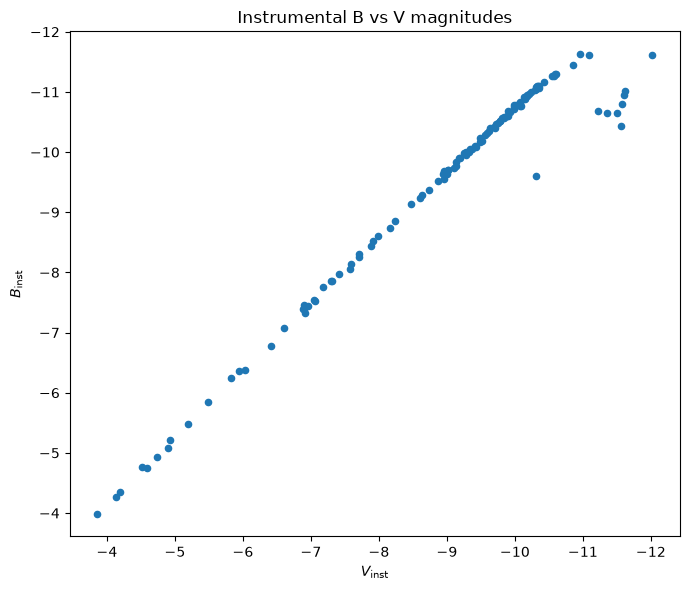

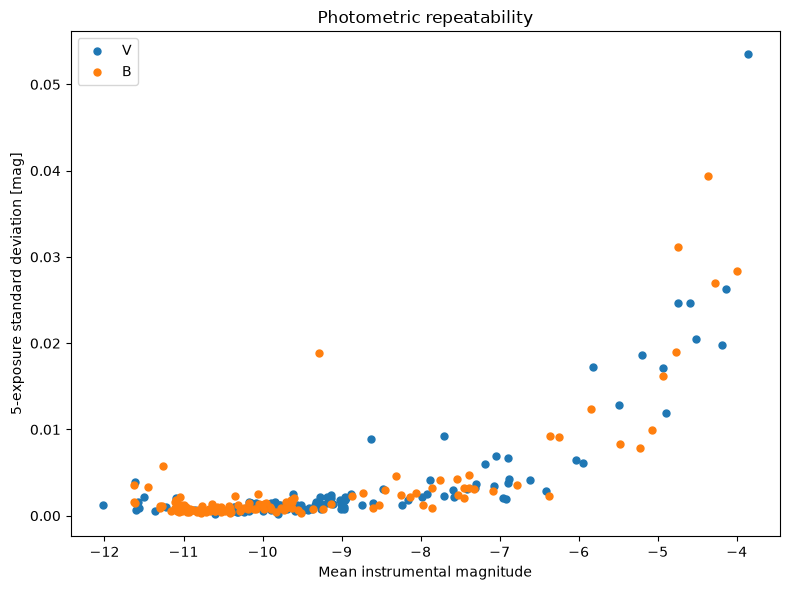

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(mean_inst_mag["V"], mean_inst_mag["B"], s=20)
plt.xlabel(r"$V_{\rm inst}$")
plt.ylabel(r"$B_{\rm inst}$")
plt.title("Instrumental B vs V magnitudes")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(mean_inst_mag["V"], std_inst_mag["V"], s=25, label="V")
plt.scatter(mean_inst_mag["B"], std_inst_mag["B"], s=25, label="B")
plt.xlabel("Mean instrumental magnitude")
plt.ylabel("5-exposure standard deviation [mag]")
plt.title("Photometric repeatability")
plt.legend()
plt.tight_layout()
plt.show()

Now, something we have to be careful of is saturation, that is, when a pixels well exceeds 60,000 ADU. In other words, we'll define a star as saturated in a given exposure if any pixel inside its 6.5-pixel photometric aperture exceeds 60,000 ADU.

In [253]:
from pathlib import Path
import ccdproc
import astropy.units as u
import numpy as np
from photutils.aperture import CircularAperture

light_dir = Path("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 2 - Optical Photometry/raw_data/light/")
light_files = sorted(light_dir.glob("*.fits"))
raw_lights_by_filter = {
    "B": [],
    "V": []
}

for light_file in light_files:
    light = ccdproc.CCDData.read(light_file, unit=u.adu)
    filt = light.meta["FILTER"]
    raw_lights_by_filter[filt].append(light_file)

print("B:", len(raw_lights_by_filter["B"]))
print("V:", len(raw_lights_by_filter["V"]))

SATURATION_LEVEL = 60000.0

saturation = {}
for filt in ["B", "V"]:
    saturation[filt] = []
    for i, light_file in enumerate(raw_lights_by_filter[filt]):
        light = ccdproc.CCDData.read(light_file, unit=u.adu)
        x = positions_by_filter[filt][i]["x"]
        y = positions_by_filter[filt][i]["y"]
        positions = np.column_stack([x, y])
        apertures = CircularAperture(positions, r=6.5)
        masks = apertures.to_mask(method="center")

        max_pixels = []
        for mask in masks:
            cutout = mask.multiply(light.data)
            pixels = cutout[mask.data > 0]
            if len(pixels) == 0:
                max_pixels.append(np.nan)
            else:
                max_pixels.append(np.nanmax(pixels))
        max_pixels = np.asarray(max_pixels)
        saturated = max_pixels >= SATURATION_LEVEL
        saturation[filt].append({
            "frame": i,
            "max_pixel": max_pixels,
            "saturated": saturated
        })

        print(
            f"{filt} frame {i+1}: "
            f"{np.sum(saturated)} saturated stars"
        )

saturated_any = {}
for filt in ["B", "V"]:
    sat_arrays = np.array([entry["saturated"] for entry in saturation[filt]])
    saturated_any[filt] = np.any(sat_arrays, axis=0)
    print(
        f"{filt}: "
        f"{np.sum(saturated_any[filt])} unique stars "
        f"saturated in at least one exposure"
    )

saturated_either = (
    saturated_any["B"] |
    saturated_any["V"]
)

n_saturated_either = np.sum(saturated_either)
n_calibration = len(saturated_either) - n_saturated_either

print("Saturated in B or V:", n_saturated_either)
print("Unsaturated in both:", n_calibration)

calibration_mask = ~saturated_either
print(f"Calibration candidates: {np.sum(calibration_mask)} / {len(calibration_mask)}")

B: 5
V: 5
B frame 1: 21 saturated stars
B frame 2: 23 saturated stars
B frame 3: 22 saturated stars
B frame 4: 23 saturated stars
B frame 5: 21 saturated stars
V frame 1: 9 saturated stars
V frame 2: 9 saturated stars
V frame 3: 9 saturated stars
V frame 4: 9 saturated stars
V frame 5: 9 saturated stars
B: 23 unique stars saturated in at least one exposure
V: 9 unique stars saturated in at least one exposure
Saturated in B or V: 29
Unsaturated in both: 94
Calibration candidates: 94 / 123


The next thing we ought to do is compute the photometric zero point, defined to be
\begin{equation}
    Z_F = m_F + 2.5 \log_{10}S,
\end{equation}
where $S$ is the measured signal in DN/s. Referencing the answer key, which reports the apparent magnitudes, will thus allow us to compute the photometric zero point.

Visually inspecting our zero point magnitudes, which we would expect to be flat lines across the apparent magnitudes of all stars:

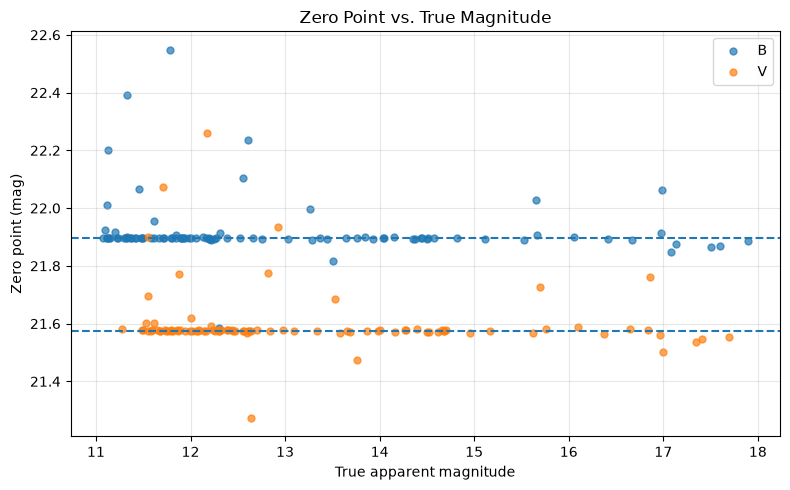

B zero point = 21.8959 ± 0.0059
V zero point = 21.5757 ± 0.0071


In [255]:
from astropy.stats import sigma_clipped_stats
import matplotlib.pyplot as plt
import numpy as np

zp_mask = (~cal_table["sat_B"] & ~cal_table["sat_V"] & (cal_table["match_sep_arcsec"] < 1.0))
zp_B = cal_table.loc[zp_mask, "ZP_B"].to_numpy()
zp_V = cal_table.loc[zp_mask, "ZP_V"].to_numpy()

_, ZP_B, ZP_B_std = sigma_clipped_stats(zp_B, sigma=3, maxiters=5)
_, ZP_V, ZP_V_std = sigma_clipped_stats(zp_V, sigma=3, maxiters=5)

plt.figure(figsize=(8, 5))
plt.scatter(cal_table.loc[zp_mask, "B_true"], zp_B, s=25, alpha=0.7, label="B")
plt.scatter(cal_table.loc[zp_mask, "V_true"], zp_V, s=25, alpha=0.7, label="V")
plt.axhline(ZP_B, linestyle="--")
plt.axhline(ZP_V, linestyle="--")
plt.xlabel("True apparent magnitude")
plt.ylabel("Zero point (mag)")
plt.title("Zero Point vs. True Magnitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"B zero point = {ZP_B:.4f} ± {ZP_B_std:.4f}")
print(f"V zero point = {ZP_V:.4f} ± {ZP_V_std:.4f}")

Our penultimate big step is calibrating all the stars. We have already computed the instrumental magnitudes:
\begin{equation}
    \begin{split}
        \begin{aligned}
            m_{B, \text{inst}} = -2.5 \log_{10}(S_B),
            \\
            m_{V, \text{inst}} = -2.5 \log_{10}(S_V),
            \\
        \end{aligned}
    \end{split}
\end{equation}
where $S$ is the background-subtracted aperture flux in ADU/s. As such, the calibrated magnitude is thus
\begin{equation}
    \begin{split}
        \begin{aligned}
            m_B = ZP_B + m_{B, \text{inst}},
            \\
            m_V = ZP_V + m_{V, \text{inst}},
            \\
        \end{aligned}
    \end{split}
\end{equation}
And so, also computing the observed color, and then plotting the magnitude versus the color:

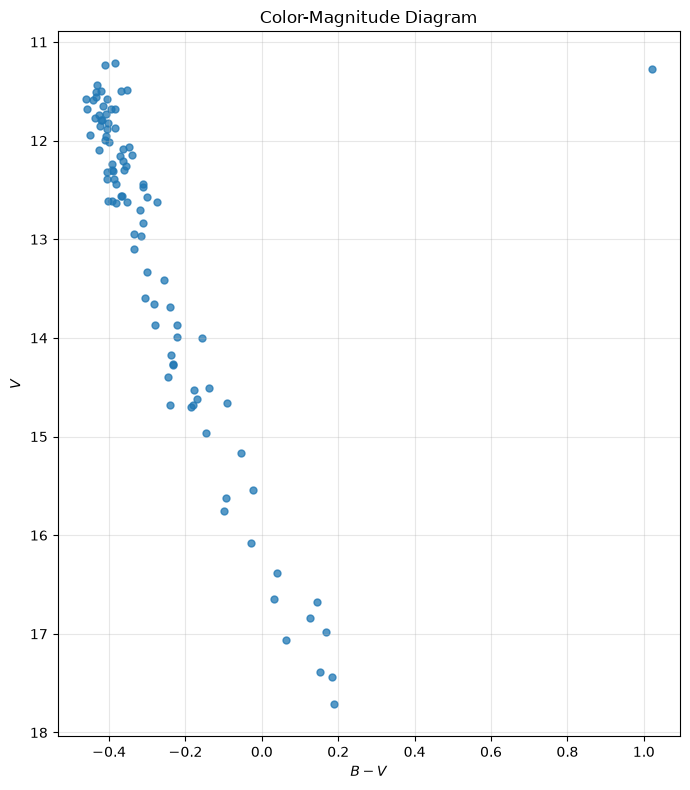

In [258]:
import matplotlib.pyplot as plt

cal_table["B_cal"] = ZP_B + cal_table["B_inst"]
cal_table["V_cal"] = ZP_V + cal_table["V_inst"]
cal_table["B_minus_V"] = (cal_table["B_cal"] - cal_table["V_cal"])

cmd_mask = (~cal_table["sat_B"] & ~cal_table["sat_V"] & np.isfinite(cal_table["B_cal"]) & np.isfinite(cal_table["V_cal"]))
plt.figure(figsize=(7, 8))
plt.scatter(cal_table.loc[cmd_mask, "B_minus_V"], cal_table.loc[cmd_mask, "V_cal"], s=25, alpha=0.75)
plt.gca().invert_yaxis()
plt.xlabel(r"$B-V$")
plt.ylabel(r"$V$")
plt.title("Color-Magnitude Diagram")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

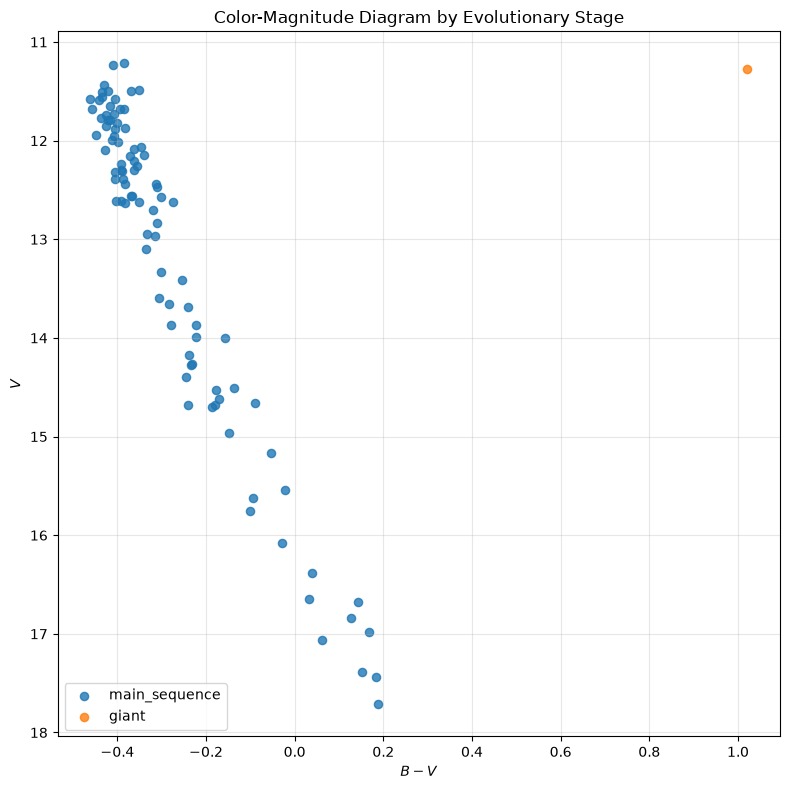

In [ ]:
plt.figure(figsize=(8, 8))

for stage in cal_table.loc[cmd_mask, "stage"].unique():
    mask = cmd_mask & (cal_table["stage"] == stage)
    plt.scatter(cal_table.loc[mask, "B_minus_V"], cal_table.loc[mask, "V_cal"], s=35, alpha=0.8, label=stage)
    
plt.gca().invert_yaxis()
plt.xlabel(r"$B-V$")
plt.ylabel(r"$V$")
plt.title("Color-Magnitude Diagram by Evolutionary Stage")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Aha! We have finally constructed a Color-Magnitude Diagram (CMD)! To check how well we did,

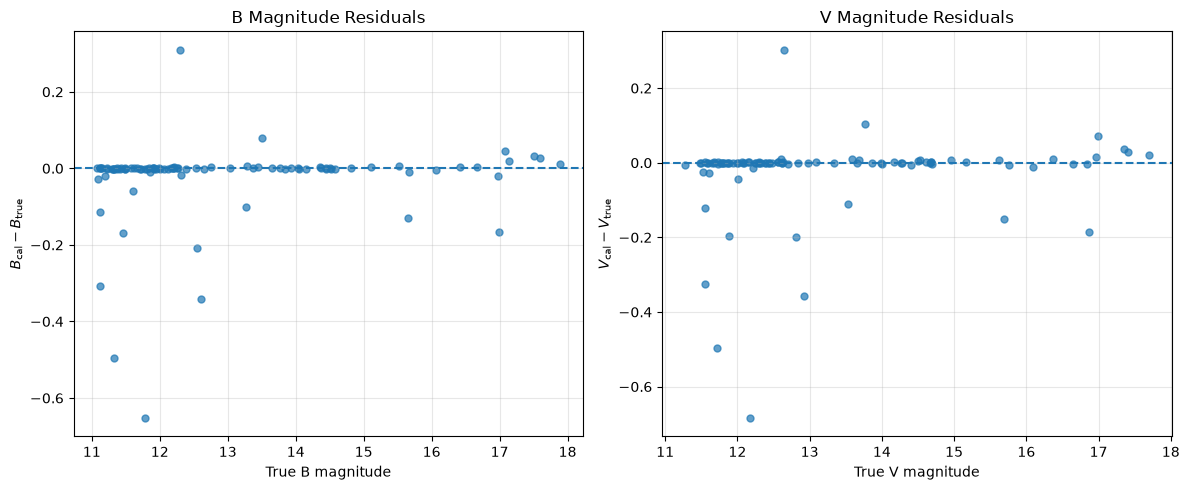

In [259]:
cal_table["dB"] = cal_table["B_cal"] - cal_table["B_true"]
cal_table["dV"] = cal_table["V_cal"] - cal_table["V_true"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(cal_table.loc[cmd_mask, "B_true"], cal_table.loc[cmd_mask, "dB"], s=25, alpha=0.7)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("True B magnitude")
axes[0].set_ylabel(r"$B_{\rm cal}-B_{\rm true}$")
axes[0].set_title("B Magnitude Residuals")
axes[0].grid(alpha=0.3)

axes[1].scatter(cal_table.loc[cmd_mask, "V_true"], cal_table.loc[cmd_mask, "dV"], s=25, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("True V magnitude")
axes[1].set_ylabel(r"$V_{\rm cal}-V_{\rm true}$")
axes[1].set_title("V Magnitude Residuals")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()